# Notebook — Teste do módulo `geoid.py`

Este notebook testa o módulo:

```python
geodesy/geoid.py
```

Serão testadas as funções:

- `bruns_formula`
- `disturbing_potential_from_geoid_height`
- `geoid_height_from_T`
- `height_anomaly_from_T`
- `geoid_to_quasigeoid`
- `quasigeoid_to_geoid`
- `ellipsoidal_to_orthometric`
- `orthometric_to_ellipsoidal`
- `geoid_residual`
- `mean_dynamic_topography`

Os exemplos usam geoide sintético, potencial perturbador, altura elipsoidal, altura ortométrica, quasigeoide e topografia dinâmica média.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import geoid
from geodesy import normal_gravity
from geodesy import constants

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Fórmula de Bruns


T min/max: 65.98287996683572 117.81245199835982
N min/max: 6.711979224876973 12.021779313870207


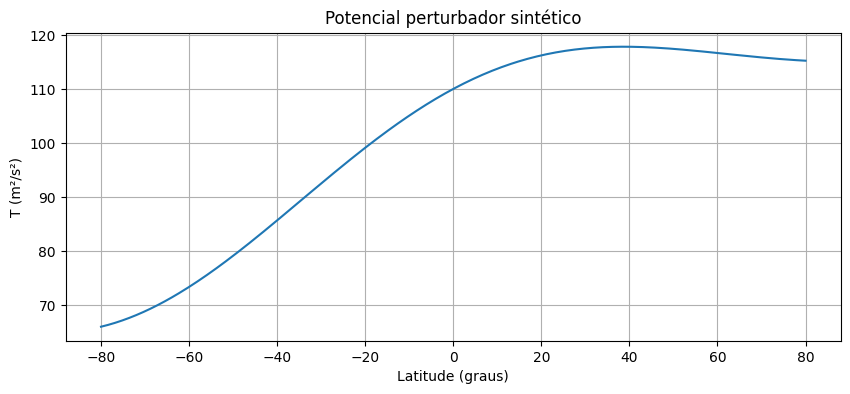

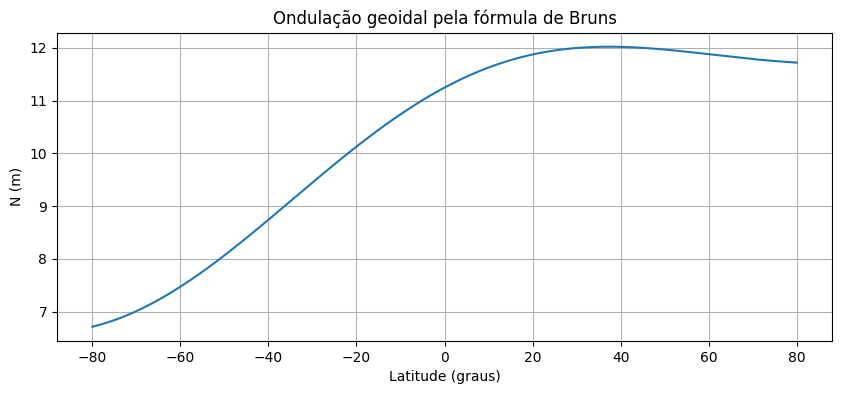

In [2]:
# ============================================================
# 1. FÓRMULA DE BRUNS
# ============================================================

lat = np.linspace(-80, 80, 300)
gamma = normal_gravity.normal_gravity_somigliana(lat)

# Potencial perturbador sintético
T = 100 + 25*np.sin(np.deg2rad(lat)) + 10*np.cos(2*np.deg2rad(lat))

N = geoid.bruns_formula(T, gamma)

print("T min/max:", T.min(), T.max())
print("N min/max:", N.min(), N.max())

plt.figure(figsize=(10, 4))
plt.plot(lat, T)
plt.xlabel("Latitude (graus)")
plt.ylabel("T (m²/s²)")
plt.title("Potencial perturbador sintético")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lat, N)
plt.xlabel("Latitude (graus)")
plt.ylabel("N (m)")
plt.title("Ondulação geoidal pela fórmula de Bruns")
plt.grid(True)
plt.show()


## 2. Potencial perturbador a partir de N


Erro máximo em T: 1.4210854715202004e-14


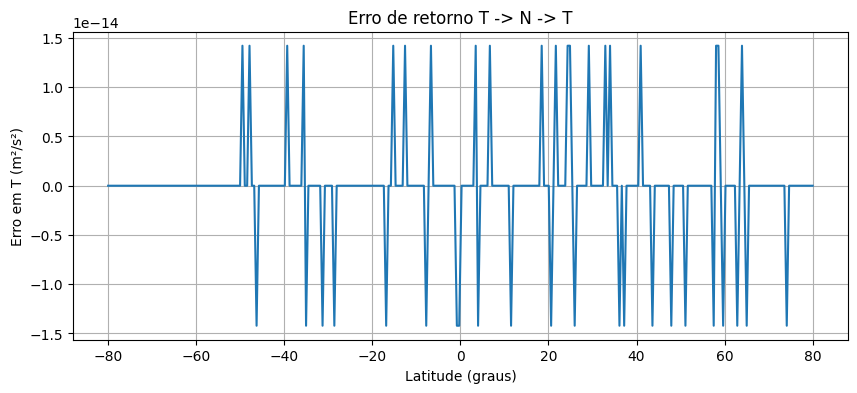

In [3]:
# ============================================================
# 2. T = N GAMMA
# ============================================================

T_back = geoid.disturbing_potential_from_geoid_height(N, gamma)

erro_T = T_back - T

print("Erro máximo em T:", np.max(np.abs(erro_T)))

plt.figure(figsize=(10, 4))
plt.plot(lat, erro_T)
plt.xlabel("Latitude (graus)")
plt.ylabel("Erro em T (m²/s²)")
plt.title("Erro de retorno T -> N -> T")
plt.grid(True)
plt.show()


## 3. Funções equivalentes `geoid_height_from_T` e `height_anomaly_from_T`


Diferença entre N e N2: 0.0
Diferença entre N e zeta nesta aproximação: 0.0


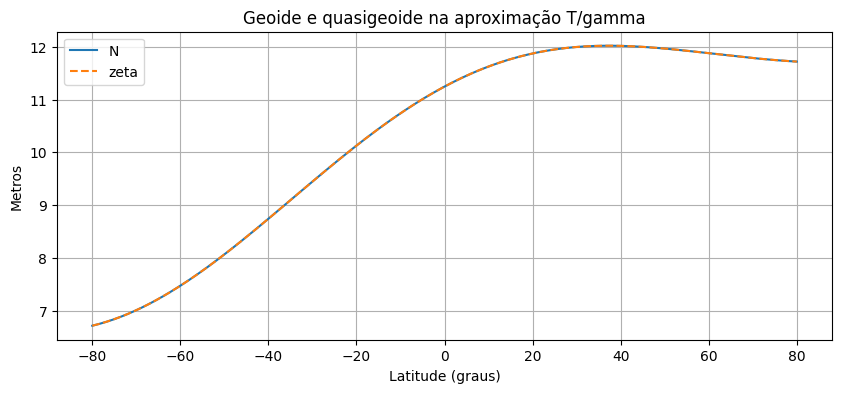

In [4]:
# ============================================================
# 3. N E ZETA A PARTIR DE T
# ============================================================

N2 = geoid.geoid_height_from_T(T, gamma)
zeta = geoid.height_anomaly_from_T(T, gamma)

print("Diferença entre N e N2:", np.max(np.abs(N - N2)))
print("Diferença entre N e zeta nesta aproximação:", np.max(np.abs(N - zeta)))

plt.figure(figsize=(10, 4))
plt.plot(lat, N2, label="N")
plt.plot(lat, zeta, linestyle="--", label="zeta")
plt.xlabel("Latitude (graus)")
plt.ylabel("Metros")
plt.title("Geoide e quasigeoide na aproximação T/gamma")
plt.legend()
plt.grid(True)
plt.show()


## 4. Conversão geoide ↔ quasigeoide


Erro máximo no retorno N -> zeta -> N:
1.7763568394002505e-15


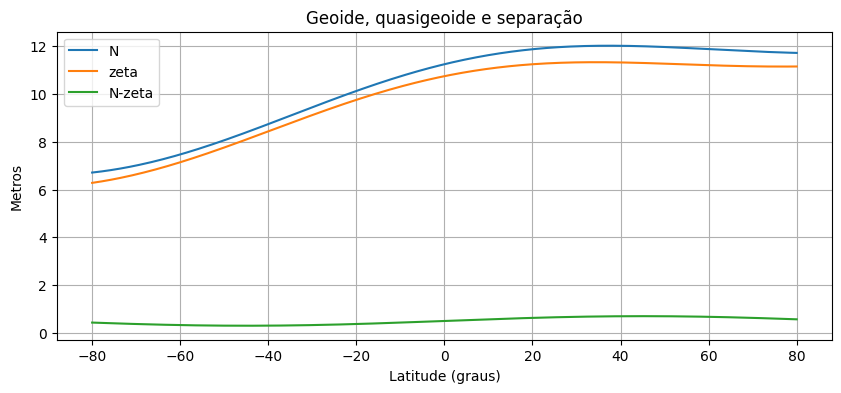

In [5]:
# ============================================================
# 4. GEOIDE E QUASIGEOIDE
# ============================================================

separation = 0.5 + 0.2*np.sin(np.deg2rad(2*lat))

zeta_from_N = geoid.geoid_to_quasigeoid(N, separation)
N_from_zeta = geoid.quasigeoid_to_geoid(zeta_from_N, separation)

print("Erro máximo no retorno N -> zeta -> N:")
print(np.max(np.abs(N_from_zeta - N)))

plt.figure(figsize=(10, 4))
plt.plot(lat, N, label="N")
plt.plot(lat, zeta_from_N, label="zeta")
plt.plot(lat, separation, label="N-zeta")
plt.xlabel("Latitude (graus)")
plt.ylabel("Metros")
plt.title("Geoide, quasigeoide e separação")
plt.legend()
plt.grid(True)
plt.show()


## 5. Relação entre altura elipsoidal, ortométrica e geoide


Erro máximo no retorno h -> H -> h:
1.4210854715202004e-14


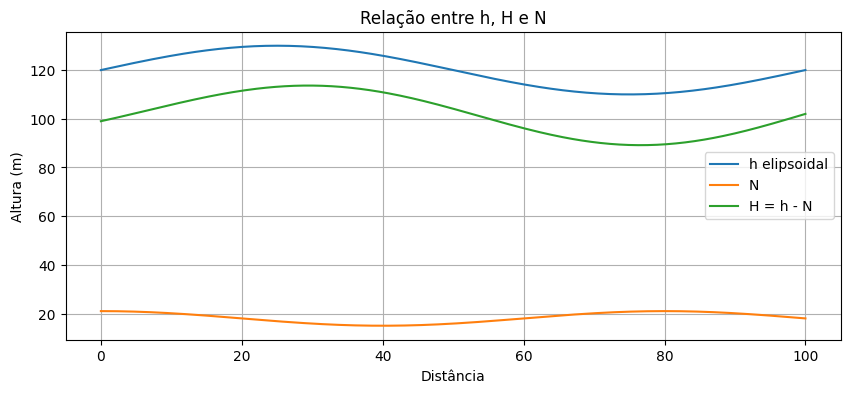

In [6]:
# ============================================================
# 5. h, H E N
# ============================================================

x = np.linspace(0, 100, 300)

h = 120 + 10*np.sin(2*np.pi*x/100)
N_profile = 18 + 3*np.cos(2*np.pi*x/80)
H = geoid.ellipsoidal_to_orthometric(h, N_profile)
h_back = geoid.orthometric_to_ellipsoidal(H, N_profile)

print("Erro máximo no retorno h -> H -> h:")
print(np.max(np.abs(h_back - h)))

plt.figure(figsize=(10, 4))
plt.plot(x, h, label="h elipsoidal")
plt.plot(x, N_profile, label="N")
plt.plot(x, H, label="H = h - N")
plt.xlabel("Distância")
plt.ylabel("Altura (m)")
plt.title("Relação entre h, H e N")
plt.legend()
plt.grid(True)
plt.show()


## 6. Resíduo geoidal


Resíduo médio: 0.010269726000404884
RMSE: 0.23240704077468685
Erro máximo: 0.7284656165018326


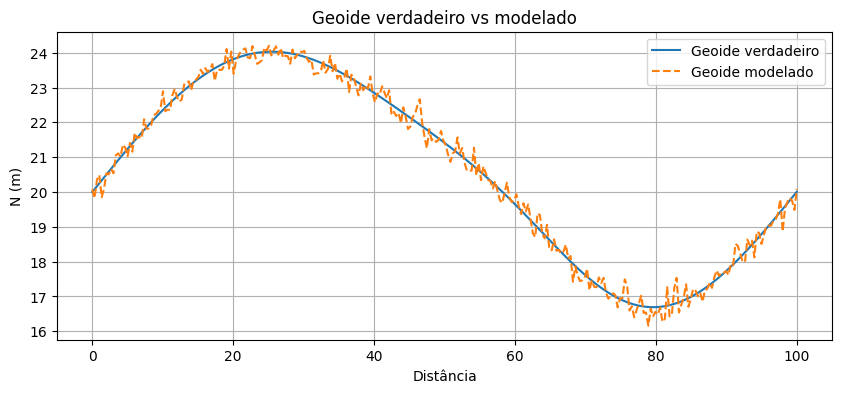

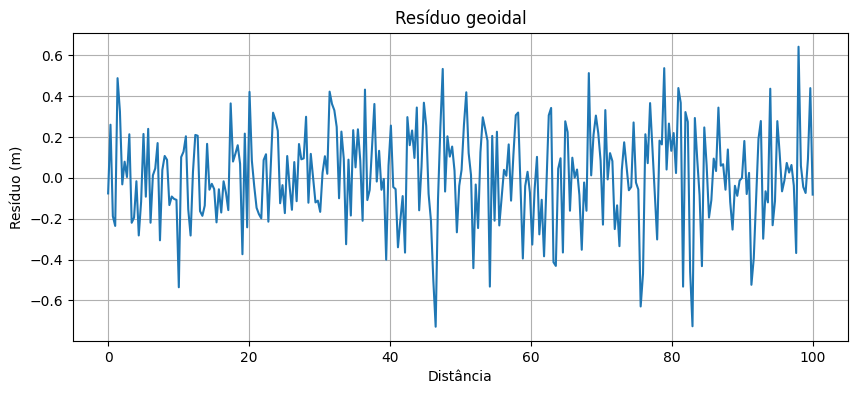

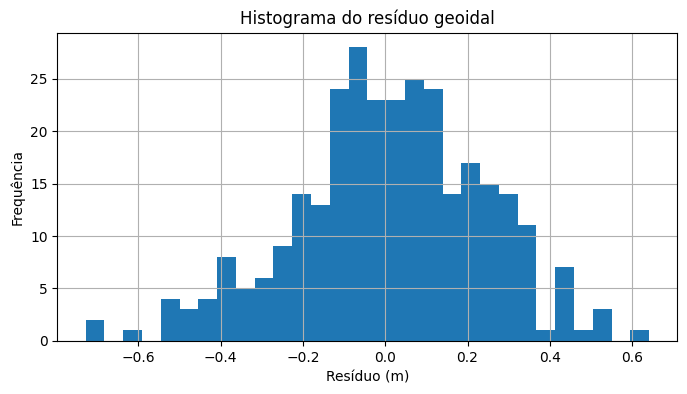

In [7]:
# ============================================================
# 6. RESÍDUO GEOIDAL
# ============================================================

rng = np.random.default_rng(42)

N_true = 20 + 4*np.sin(2*np.pi*x/100) + 2*np.exp(-0.5*((x-60)/12)**2)
N_model = N_true + rng.normal(0, 0.25, size=len(x))

res = geoid.geoid_residual(N_true, N_model)

print("Resíduo médio:", np.mean(res))
print("RMSE:", np.sqrt(np.mean(res**2)))
print("Erro máximo:", np.max(np.abs(res)))

plt.figure(figsize=(10, 4))
plt.plot(x, N_true, label="Geoide verdadeiro")
plt.plot(x, N_model, linestyle="--", label="Geoide modelado")
plt.xlabel("Distância")
plt.ylabel("N (m)")
plt.title("Geoide verdadeiro vs modelado")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, res)
plt.xlabel("Distância")
plt.ylabel("Resíduo (m)")
plt.title("Resíduo geoidal")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(res, bins=30)
plt.xlabel("Resíduo (m)")
plt.ylabel("Frequência")
plt.title("Histograma do resíduo geoidal")
plt.grid(True)
plt.show()


## 7. Topografia dinâmica média


MDT min/max: -0.9999779207220207 0.5999999999238277


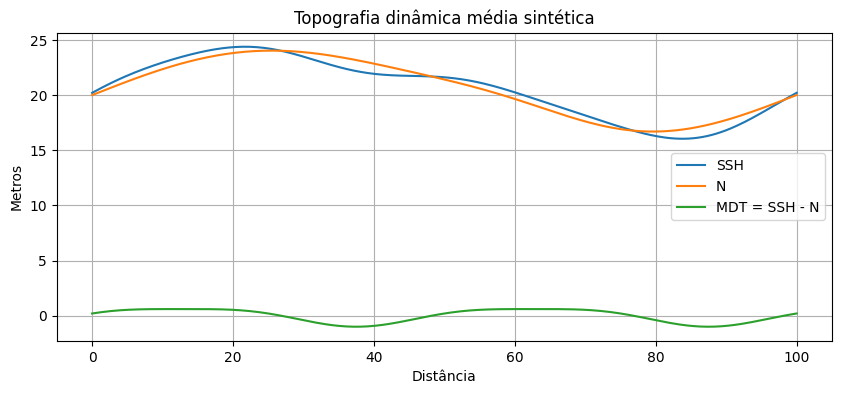

In [8]:
# ============================================================
# 7. MEAN DYNAMIC TOPOGRAPHY
# ============================================================

# Superfície média do mar sintética
SSH = N_true + 0.8*np.sin(2*np.pi*x/50) + 0.2*np.cos(2*np.pi*x/25)

MDT = geoid.mean_dynamic_topography(SSH, N_true)

print("MDT min/max:", MDT.min(), MDT.max())

plt.figure(figsize=(10, 4))
plt.plot(x, SSH, label="SSH")
plt.plot(x, N_true, label="N")
plt.plot(x, MDT, label="MDT = SSH - N")
plt.xlabel("Distância")
plt.ylabel("Metros")
plt.title("Topografia dinâmica média sintética")
plt.legend()
plt.grid(True)
plt.show()


## 8. Mapa sintético de geoide


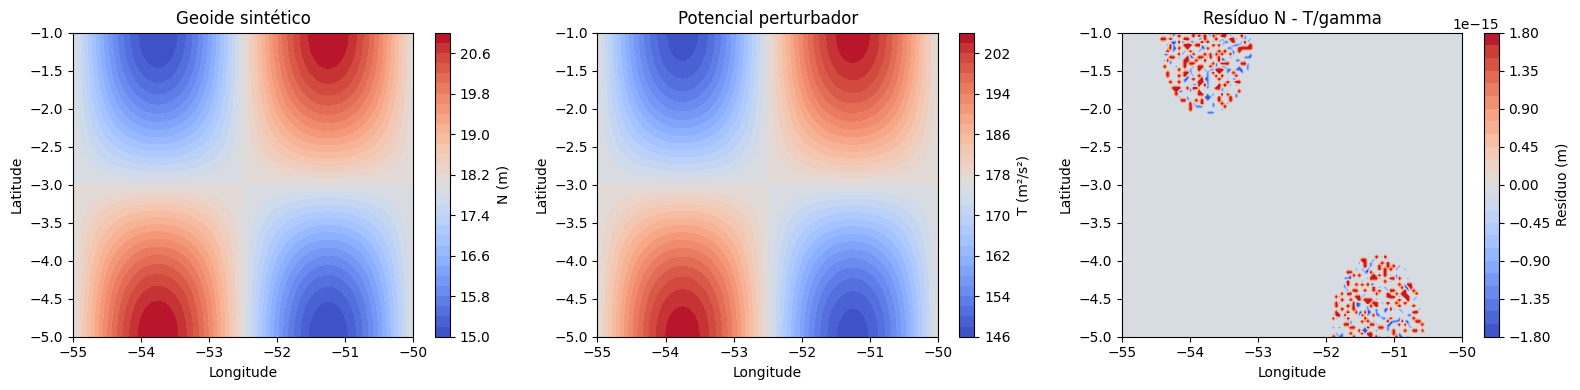

Erro máximo na recuperação: 1.7763568394002505e-15


In [10]:
# ============================================================
# 8. MAPA SINTÉTICO DE GEOIDE
# ============================================================

lon = np.linspace(-55, -50, 120)
lat2 = np.linspace(-5, -1, 100)
LON, LAT = np.meshgrid(lon, lat2)

N_grid = 18 + 3*np.sin((LON+55)*2*np.pi/5) * np.cos((LAT+5)*np.pi/4)
gamma_grid = normal_gravity.normal_gravity_somigliana(LAT)
T_grid = geoid.disturbing_potential_from_geoid_height(N_grid, gamma_grid)
N_recovered = geoid.bruns_formula(T_grid, gamma_grid)
res_grid = geoid.geoid_residual(N_grid, N_recovered)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, N_grid, cmap="coolwarm", levels=30)
plt.colorbar(c1, label="N (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide sintético")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, T_grid, cmap="coolwarm", levels=30)
plt.colorbar(c2, label="T (m²/s²)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Potencial perturbador")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, res_grid, cmap="coolwarm", levels=30)
plt.colorbar(c3, label="Resíduo (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Resíduo N - T/gamma")

plt.tight_layout()
plt.show()

print("Erro máximo na recuperação:", np.nanmax(np.abs(res_grid)))


## 9. Mapa sintético de h, N e H


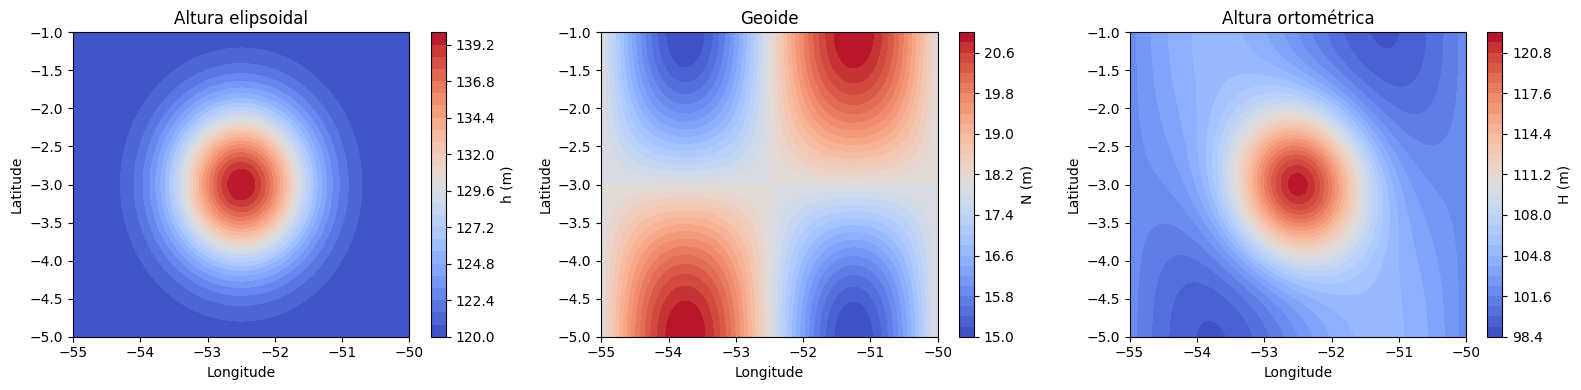

In [11]:
# ============================================================
# 9. MAPA DE h, N E H
# ============================================================

h_grid = 120 + 20*np.exp(-((LON+52.5)**2 + (LAT+3.0)**2)/1.0)
H_grid = geoid.ellipsoidal_to_orthometric(h_grid, N_grid)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, h_grid, cmap="coolwarm", levels=30)
plt.colorbar(c1, label="h (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Altura elipsoidal")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, N_grid, cmap="coolwarm", levels=30)
plt.colorbar(c2, label="N (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, H_grid, cmap="coolwarm", levels=30)
plt.colorbar(c3, label="H (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Altura ortométrica")

plt.tight_layout()
plt.show()


## 10. Resumo final


Se todas as células foram executadas sem erro, o módulo `geoid.py` está funcionando corretamente.

Os próximos notebooks podem testar:

```python
geodesy/spherical_harmonics.py
geodesy/terrain_effects.py
```
